# APO Benchmark — Results Analysis

Dimensions: **accuracy** (test score), **stability** (seed variance), **efficiency** (tokens/calls), **speed** (wall-clock), **generalization** (dev–test gap).

Set `RUN_CUTOFF` to exclude results written before the last clean launch.

In [15]:
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path

OUTPUTS = Path('../outputs/proposal_comparison_3bench_qwen3-4-instruct')
RUN_CUTOFF = None  # e.g. '2026-07-08 22:00' — exclude older files

cutoff_ts = datetime.fromisoformat(RUN_CUTOFF).timestamp() if RUN_CUTOFF else 0

rows = []
for f in sorted(OUTPUTS.rglob('result_*.json')):
    if f.stat().st_mtime < cutoff_ts:
        continue
    rel = f.relative_to(OUTPUTS).parts
    # Layout: [model/]method/task/seed_N/result_*.json
    if len(rel) == 5:
        model, method, task, seed_dir = rel[0], rel[1], rel[2], rel[3]
    else:
        model, method, task, seed_dir = 'default', rel[0], rel[1], rel[2]
    d = json.loads(f.read_text(encoding='utf-8'))
    usage = d.get('llm_usage') or {}
    rows.append({
        'model': model,
        'method': method,
        'task': task.replace('bbh_', ''),
        'seed': int(seed_dir.replace('seed_', '')),
        'dev': d.get('best_score', 0.0),
        'test': d.get('test_score', 0.0),
        'time_s': d.get('total_time', 0.0),
        'calls': usage.get('total_calls', 0),
        'tokens_in': usage.get('total_input_tokens', 0),
        'tokens_out': usage.get('total_output_tokens', 0),
        'tokens': usage.get('total_tokens', 0),
        'iters': d.get('num_iterations', 0),
        'empty_prompt': d.get('best_prompt', '') == '',
        'mtime': datetime.fromtimestamp(f.stat().st_mtime),
    })

df = pd.DataFrame(rows)
if len(df) and df['empty_prompt'].any():
    print(f"WARNING: {int(df['empty_prompt'].sum())} runs have empty best_prompt (stripping-bug era) — set RUN_CUTOFF")
print(f'{len(df)} runs | methods={sorted(df.method.unique())} | tasks={sorted(df.task.unique())}')
print(f'written {df.mtime.min()} → {df.mtime.max()}')

# Completeness check: every method×task should have the same number of seeds
counts = df.pivot_table(index='task', columns='method', values='seed', aggfunc='count')
counts = counts.reindex(index=sorted(df.task.unique()), columns=sorted(df.method.unique()))
expected = int(counts.max().max())
inc = counts.fillna(-1).stack()
inc = inc[inc < expected]
if len(inc):
    print(f'\nINCOMPLETE cells (expected {expected} seeds; -1 = no runs at all):')
    print(inc.astype(int).to_string())
df.head(3)

123 runs | methods=['apex', 'baseline', 'capo', 'gaapo', 'gspe', 'see', 'swift'] | tasks=['causal_judgement', 'disambiguation_qa', 'formal_fallacies', 'gsm8k', 'humaneval', 'hyperbaton']
written 2026-07-10 09:05:48.194128 → 2026-07-12 20:42:47.962237

INCOMPLETE cells (expected 3 seeds; -1 = no runs at all):
task       method
humaneval  gspe     -1


,model,method,task,seed,dev,test,time_s,calls,tokens_in,tokens_out,tokens,iters,empty_prompt,mtime
0,default,apex,causal_judgement,123,0.68,0.582609,469.46,621,1151134,16919,1168053,5,False,2026-07-10 09:06:16.548965
1,default,apex,causal_judgement,42,0.68,0.678261,485.48,706,1176384,18592,1194976,5,False,2026-07-10 09:06:15.618966
2,default,apex,causal_judgement,7,0.72,0.600000,489.56,496,1084110,16359,1100469,5,False,2026-07-10 09:06:14.864348


## 1. Accuracy — test score (mean ± std across seeds)

In [16]:
agg = df.groupby(['method', 'task'])['test'].agg(['mean', 'std', 'count']).reset_index()
agg['std'] = agg['std'].fillna(0.0)
agg['fmt'] = agg.apply(lambda r: f"{r['mean']:.3f} ± {r['std']:.3f}", axis=1)

pivot = agg.pivot(index='task', columns='method', values='fmt')
macro = df.groupby('method')['test'].mean()
pivot.loc['** macro avg **'] = {m: f'{macro[m]:.3f}' for m in pivot.columns}
print('Test score (mean ± std over seeds)')
pivot

Test score (mean ± std over seeds)


method,apex,baseline,capo,gaapo,gspe,see,swift
task,,,,,,,
causal_judgement,0.620 ± 0.051,0.121 ± 0.012,0.606 ± 0.027,0.626 ± 0.030,0.577 ± 0.027,0.594 ± 0.013,0.626 ± 0.009
disambiguation_qa,0.571 ± 0.118,0.630 ± 0.036,0.614 ± 0.039,0.591 ± 0.035,0.536 ± 0.028,0.583 ± 0.040,0.606 ± 0.035
formal_fallacies,0.652 ± 0.009,0.290 ± 0.017,0.658 ± 0.031,0.675 ± 0.018,0.641 ± 0.028,0.638 ± 0.036,0.646 ± 0.041
gsm8k,0.942 ± 0.013,0.460 ± 0.000,0.919 ± 0.005,0.933 ± 0.020,0.919 ± 0.013,0.939 ± 0.017,0.939 ± 0.017
humaneval,0.899 ± 0.013,0.667 ± 0.000,0.849 ± 0.013,0.884 ± 0.028,NaN,0.890 ± 0.035,0.872 ± 0.018
hyperbaton,0.878 ± 0.023,0.677 ± 0.042,0.829 ± 0.056,0.855 ± 0.028,0.855 ± 0.053,0.878 ± 0.023,0.861 ± 0.023
** macro avg **,0.760,0.474,0.746,0.761,0.706,0.754,0.758


## 2. Per-task best method — std-aware

With 3 seeds a raw argmax on the mean is fragile: it ignores variance and breaks exact ties arbitrarily. This cell:

1. Picks the winner by **lower confidence bound** $LCB = \bar{x} - s/\sqrt{n}$ — among methods with similar means, the more *reliable* one wins;
2. Reports exact **co-winners** explicitly (equal mean and std);
3. Lists every method whose mean is within one pooled standard error ($SE = \sqrt{s_a^2/n_a + s_b^2/n_b}$) of the top mean as a **statistical tie** — where ties exist, the data cannot support claiming a single winner.

In [17]:
def best_with_ties(task_df):
    g = task_df.groupby('method')['test'].agg(['mean', 'std', 'count'])
    g['std'] = g['std'].fillna(0.0)
    g['lcb'] = g['mean'] - g['std'] / np.sqrt(g['count'])

    top_mean = g['mean'].max()

    # Winner: highest LCB — variance-penalized, so between equal means the
    # lower-std method wins instead of an arbitrary ordering pick.
    winner = g['lcb'].idxmax()
    w = g.loc[winner]

    # Exact co-winners: same mean AND same std as the winner (within fp noise)
    co = [m for m, r in g.iterrows() if m != winner
          and abs(r['mean'] - w['mean']) < 1e-9 and abs(r['std'] - w['std']) < 1e-9]

    # Statistical ties: mean within one pooled SE of the TOP mean
    ties = []
    for m, r in g.iterrows():
        if m == winner or m in co:
            continue
        se = math.sqrt(w['std']**2 / max(w['count'], 1) + r['std']**2 / max(r['count'], 1))
        if top_mean - r['mean'] <= se:
            ties.append(f"{m} ({r['mean']:.3f}±{r['std']:.3f})")

    label = winner if not co else ' = '.join([winner] + co)
    return label, w, ties

records = []
for task, tdf in df.groupby('task'):
    label, w, ties = best_with_ties(tdf)
    records.append({
        'task': task,
        'best (by LCB)': label,
        'test': f"{w['mean']:.3f} ± {w['std']:.3f}",
        'LCB': round(w['lcb'], 3),
        'statistically tied (±1 SE)': ', '.join(ties) if ties else '— (clear winner)',
    })
pd.set_option('display.max_colwidth', 90)
best_table = pd.DataFrame(records).set_index('task')
best_table

,best (by LCB),test,LCB,statistically tied (±1 SE)
task,,,,
causal_judgement,swift,0.626 ± 0.009,0.621,"apex (0.620±0.051), gaapo (0.626±0.030)"
disambiguation_qa,baseline,0.630 ± 0.036,0.609,"apex (0.571±0.118), capo (0.614±0.039), swift (0.606±0.035)"
formal_fallacies,gaapo,0.675 ± 0.018,0.665,capo (0.658±0.031)
gsm8k,apex,0.942 ± 0.013,0.934,"gaapo (0.933±0.020), see (0.939±0.017), swift (0.939±0.017)"
humaneval,apex,0.899 ± 0.013,0.891,"gaapo (0.884±0.028), see (0.890±0.035)"
hyperbaton,apex = see,0.878 ± 0.023,0.865,"gspe (0.855±0.053), swift (0.861±0.023)"


## 2b. Best results per task — top run and its winning prompt

For each task: the single best run (highest test score across all methods and seeds) and the actual optimized prompt it produced. Note the framing difference vs §2: this is "the best prompt we found" (one lucky run), while §2 answers "which method is reliably best" (LCB over seeds) — they can legitimately disagree.

In [18]:
# Best single run per task (highest test score across all methods and seeds)
best_runs_table = (df.loc[df.groupby('task')['test'].idxmax(),
                          ['task', 'method', 'seed', 'dev', 'test', 'calls', 'tokens', 'time_s']]
                     .set_index('task')
                     .sort_values('test', ascending=False))
print('Best run per task')
best_runs_table.round(3)

Best run per task


,method,seed,dev,test,calls,tokens,time_s
task,,,,,,,
gsm8k,apex,42,0.940,0.957,361,641953,3602.430
humaneval,see,42,0.913,0.930,429,517501,3599.980
hyperbaton,gspe,7,0.880,0.913,1108,344824,336.980
formal_fallacies,gaapo,42,0.720,0.696,2652,1044503,880.340
causal_judgement,apex,42,0.680,0.678,706,1194976,485.480
disambiguation_qa,baseline,42,0.609,0.660,123,45942,1.655


In [19]:
# Per-task best run: the winning optimized prompt, verbatim.
# These are the artifacts the whole pipeline exists to produce — worth reading:
# they show WHAT each optimizer discovered (format rules, added exemplars, etc.)
best_runs = df.loc[df.groupby('task')['test'].idxmax()]

for _, r in best_runs.iterrows():
    # Reload the result file to get the prompt text
    seed_dir = f"seed_{r['seed']}"
    base = OUTPUTS if r['model'] == 'default' else OUTPUTS / r['model']
    matches = list((base / r['method']).glob(f"*{r['task']}*/{seed_dir}/result_*.json"))
    prompt = ''
    if matches:
        prompt = json.loads(matches[0].read_text(encoding='utf-8')).get('best_prompt', '')
    print('=' * 78)
    print(f"TASK: {r['task']}  |  {r['method']} seed={r['seed']}  |  "
          f"test={r['test']:.3f} (dev={r['dev']:.3f})")
    print('=' * 78)
    print(prompt if prompt else '[prompt not found]')
    print()

TASK: causal_judgement  |  apex seed=42  |  test=0.678 (dev=0.680)
Determine whether a typical person would answer "Yes" or "No" to the given question about causation.

Examples:
Input: How would a typical person answer each of the following questions about causation?
Tom works for a demolition company, and today he is demolishing a building by implosion. The building will implode automatically at 5:00 PM if both the safety switch is off and knob A is switched on. At 4:00 PM, the safety switch is off, and knob A is on. At that time, Tom checks to see if knob A is on, and he sees that it's on. So, he does not change the position of knob A at all. Because the building would implode if both the safety switch is off and knob A is switched on, the building implodes at 5:00 PM. Did the building implode because Tom did not change the position of knob A?
Options:
- Yes
- No
Output: Yes

Answer with ONLY the final answer, exactly in the same format as these examples: 'Yes', 'No', 'Yes'. No expl

## 3. Cost analysis

Budget per method plus cost-effectiveness. Output tokens are broken out — they dominate real API costs (3–5× input price on most providers). `cost_index` is relative to the cheapest method.

In [20]:
cost = df.groupby('method').agg(
    test_mean=('test', 'mean'),
    calls=('calls', 'mean'),
    tokens_in=('tokens_in', 'mean'),
    tokens_out=('tokens_out', 'mean'),
    tokens=('tokens', 'mean'),
    time_min=('time_s', lambda s: s.mean() / 60),
).round(1)
cost['score_per_100k_tok'] = (cost['test_mean'] / (cost['tokens'] / 100_000)).round(3)
cost['score_per_min'] = (cost['test_mean'] / cost['time_min']).round(3)
cost['cost_index'] = (cost['tokens'] / cost['tokens'].min()).round(2)
cost['test_mean'] = cost['test_mean'].round(3)
cost.sort_values('score_per_100k_tok', ascending=False)

,test_mean,calls,tokens_in,tokens_out,tokens,time_min,score_per_100k_tok,score_per_min,cost_index
method,,,,,,,,,
baseline,0.5,110.8,47080.2,11247.2,58327.3,0.5,0.857,1.000,1.00
gspe,0.7,939.4,483838.2,45403.4,529241.6,18.5,0.132,0.038,9.07
apex,0.8,475.9,659106.3,116681.6,775787.9,24.6,0.103,0.033,13.30
see,0.8,763.3,681087.7,94686.1,775773.8,26.3,0.103,0.030,13.30
swift,0.8,401.9,730526.3,106671.6,837197.8,23.4,0.096,0.034,14.35
gaapo,0.8,1782.4,799657.2,71724.2,871381.4,30.1,0.092,0.027,14.94
capo,0.7,1442.4,969228.7,65156.1,1034384.7,30.9,0.068,0.023,17.73


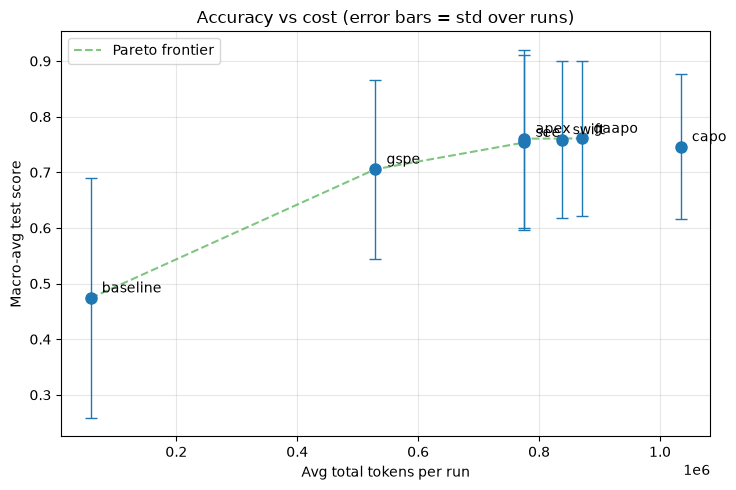

Pareto-efficient: baseline, gspe, see, apex, gaapo


In [21]:
# Pareto frontier: methods below/right of the line are dominated —
# something else is both cheaper AND more accurate.
fig, ax = plt.subplots(figsize=(7.5, 5))
pts = df.groupby('method').agg(tokens=('tokens', 'mean'), test=('test', 'mean'),
                               test_std=('test', 'std'))
ax.errorbar(pts['tokens'], pts['test'], yerr=pts['test_std'].fillna(0),
            fmt='o', capsize=4, markersize=8, lw=1)
for m, r in pts.iterrows():
    ax.annotate(m, (r['tokens'], r['test']), textcoords='offset points',
                xytext=(8, 4), fontsize=10)
frontier = []
for m, r in pts.sort_values('tokens').iterrows():
    if not frontier or r['test'] > frontier[-1][1]:
        frontier.append((r['tokens'], r['test'], m))
fx, fy, fm = zip(*frontier)
ax.plot(fx, fy, '--', color='tab:green', alpha=0.6, label='Pareto frontier')
ax.set_xlabel('Avg total tokens per run')
ax.set_ylabel('Macro-avg test score')
ax.set_title('Accuracy vs cost (error bars = std over runs)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('Pareto-efficient:', ', '.join(fm))

## 4. Generalization — dev → test gap (positive = overfit to dev)

In [22]:
gap = df.groupby(['method', 'task']).agg(dev=('dev', 'mean'), test=('test', 'mean')).reset_index()
gap['gap'] = (gap['dev'] - gap['test']).round(3)
gap_pivot = gap.pivot(index='task', columns='method', values='gap')
gap_pivot.loc['** mean gap **'] = gap_pivot.mean().round(3)
gap_pivot.style.background_gradient(cmap='RdYlGn_r', axis=None).format('{:.3f}')

method,apex,baseline,capo,gaapo,gspe,see,swift
task,,,,,,,
causal_judgement,0.073,0.097,0.104,0.087,0.103,0.146,0.087
disambiguation_qa,0.096,0.080,0.037,0.082,0.017,0.084,0.074
formal_fallacies,0.088,-0.087,0.019,0.051,0.079,0.076,0.060
gsm8k,0.011,0.236,0.038,0.033,0.028,0.021,0.021
humaneval,0.029,0.029,0.031,0.036,nan,0.038,0.055
hyperbaton,0.048,-0.039,0.039,0.065,0.052,0.042,0.066
** mean gap **,0.058,0.053,0.045,0.059,0.056,0.068,0.060


## 5. Stability — seed sensitivity (lower = more reproducible)

In [23]:
per_task_std = df.groupby(['method', 'task'])['test'].std().fillna(0.0)
stability = per_task_std.groupby('method').agg(['mean', 'max']).round(3)
stability.columns = ['avg_std_across_tasks', 'worst_task_std']
stability.sort_values('avg_std_across_tasks')

,avg_std_across_tasks,worst_task_std
method,,
baseline,0.018,0.042
swift,0.024,0.041
gaapo,0.026,0.035
see,0.027,0.040
capo,0.028,0.056
gspe,0.030,0.053
apex,0.038,0.118


## 6. Head-to-head — paired wins over shared (task, seed) pairs

Pairing removes task difficulty and seed luck. Cell = ROW wins vs COLUMN; † = two-sided sign test p < 0.05.

In [24]:
def sign_test_p(wins, losses):
    n = wins + losses
    if n == 0:
        return 1.0
    k = min(wins, losses)
    p = sum(math.comb(n, i) for i in range(k + 1)) / 2**n
    return min(1.0, 2 * p)

wide = df.pivot_table(index=['task', 'seed'], columns='method', values='test')
methods = sorted(df.method.unique())
h2h = pd.DataFrame(index=methods, columns=methods, dtype=object)
for a in methods:
    for b in methods:
        if a == b:
            h2h.loc[a, b] = '—'
            continue
        pair = wide[[a, b]].dropna()
        wins = int((pair[a] > pair[b]).sum())
        losses = int((pair[a] < pair[b]).sum())
        sig = ' †' if sign_test_p(wins, losses) < 0.05 else ''
        h2h.loc[a, b] = f'{wins}-{losses}{sig}'
print('row beats column (wins-losses; † = sign test p<0.05)')
h2h

row beats column (wins-losses; † = sign test p<0.05)


,apex,baseline,capo,gaapo,gspe,see,swift
apex,—,10-2 †,12-4,9-8,9-2,11-6,10-7
baseline,2-10 †,—,2-10 †,2-10 †,2-8,2-10 †,2-10 †
capo,4-12,10-2 †,—,4-11,9-5,8-9,6-8
gaapo,8-9,10-2 †,11-4,—,12-2 †,9-6,7-7
gspe,2-9,8-2,5-9,2-12 †,—,3-11,2-13 †
see,6-11,10-2 †,9-8,6-9,11-3,—,6-7
swift,7-10,10-2 †,8-6,7-7,13-2 †,7-6,—


## 7. Best method across ALL dimensions

Rank per dimension (1 = best), composite = weighted mean rank. Adjust `WEIGHTS` to your priorities.

In [25]:
WEIGHTS = {
    'accuracy': 0.40,        # macro test (higher better)
    'stability': 0.20,       # avg seed std (lower better)
    'generalization': 0.15,  # dev-test gap (lower better)
    'token_cost': 0.15,      # avg tokens (lower better)
    'speed': 0.10,           # wall-clock (lower better)
}
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9

dims = pd.DataFrame({
    'accuracy': df.groupby('method')['test'].mean(),
    'stability': per_task_std.groupby('method').mean(),
    'generalization': df.groupby('method')['dev'].mean() - df.groupby('method')['test'].mean(),
    'token_cost': df.groupby('method')['tokens'].mean(),
    'speed': df.groupby('method')['time_s'].mean(),
})
ranks = pd.DataFrame({
    'accuracy': dims['accuracy'].rank(ascending=False),
    'stability': dims['stability'].rank(),
    'generalization': dims['generalization'].rank(),
    'token_cost': dims['token_cost'].rank(),
    'speed': dims['speed'].rank(),
})
ranks['composite'] = sum(ranks[d] * w for d, w in WEIGHTS.items())
overall = pd.concat([dims.round(3), ranks.round(2).add_prefix('rank_')], axis=1)
overall = overall.sort_values('rank_composite')
print(f'Overall best considering all dimensions: {overall.index[0]}')
overall

Overall best considering all dimensions: gaapo


,accuracy,stability,generalization,token_cost,speed,rank_accuracy,rank_stability,rank_generalization,rank_token_cost,rank_speed,rank_composite
method,,,,,,,,,,,
gaapo,0.761,0.026,0.059,871381.389,1806.221,1.0,3.0,5.0,6.0,6.0,3.25
baseline,0.474,0.018,0.053,58327.333,31.586,7.0,1.0,2.0,1.0,1.0,3.55
swift,0.758,0.024,0.061,837197.833,1402.718,3.0,2.0,6.0,5.0,3.0,3.55
apex,0.760,0.038,0.058,775787.944,1475.344,2.0,7.0,4.0,4.0,4.0,3.80
see,0.754,0.027,0.068,775773.778,1576.302,4.0,4.0,7.0,3.0,5.0,4.40
gspe,0.706,0.030,0.056,529241.600,1112.005,6.0,6.0,3.0,2.0,2.0,4.55
capo,0.746,0.028,0.045,1034384.722,1854.679,5.0,5.0,1.0,7.0,7.0,4.90


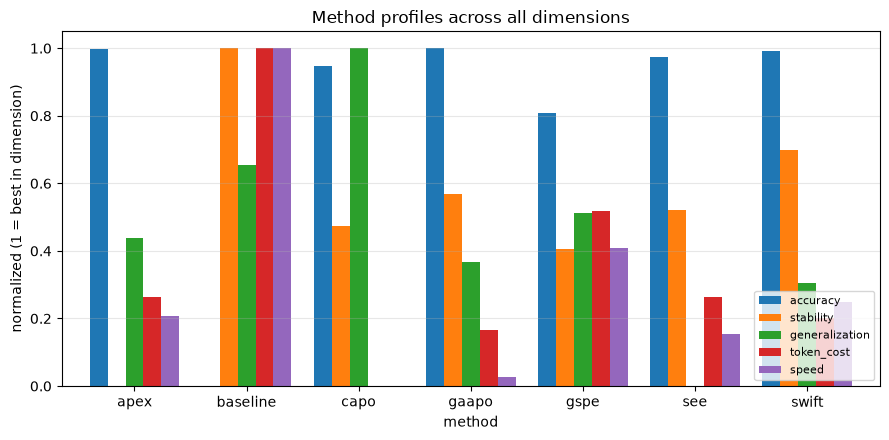

In [26]:
# Normalized profiles: 1.0 = best method on that dimension.
norm = pd.DataFrame(index=dims.index)
rng_ = dims['accuracy'].max() - dims['accuracy'].min() + 1e-12
norm['accuracy'] = (dims['accuracy'] - dims['accuracy'].min()) / rng_
for c in ['stability', 'generalization', 'token_cost', 'speed']:
    rng_ = dims[c].max() - dims[c].min() + 1e-12
    norm[c] = 1 - (dims[c] - dims[c].min()) / rng_

ax = norm.plot(kind='bar', figsize=(9, 4.5), width=0.8)
ax.set_ylabel('normalized (1 = best in dimension)')
ax.set_title('Method profiles across all dimensions')
ax.legend(loc='lower right', fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

## 8. Convergence — value added per generation

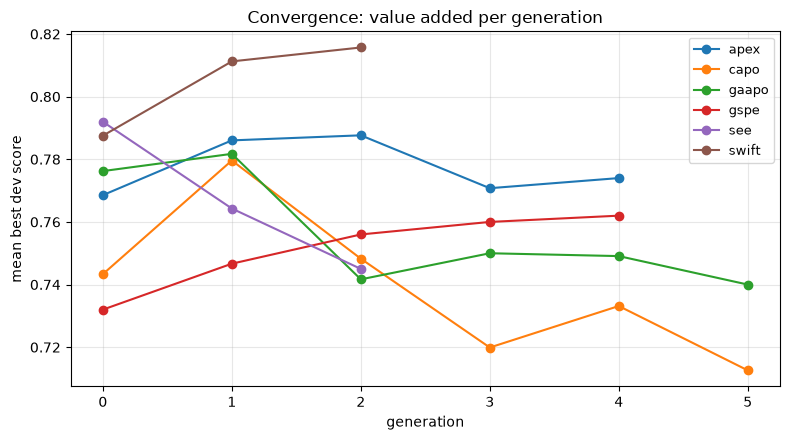

In [27]:
trajs = []
for f in sorted(OUTPUTS.rglob('result_*.json')):
    if f.stat().st_mtime < cutoff_ts:
        continue
    rel = f.relative_to(OUTPUTS).parts
    method = rel[1] if len(rel) == 5 else rel[0]
    d = json.loads(f.read_text(encoding='utf-8'))
    for g in d.get('optimization_history', []):
        trajs.append({'method': method, 'generation': g['generation'],
                      'best_score': g['best_score']})
tdf = pd.DataFrame(trajs)
if len(tdf):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for m, g in tdf.groupby('method'):
        curve = g.groupby('generation')['best_score'].mean()
        ax.plot(curve.index, curve.values, marker='o', label=m)
    ax.set_xlabel('generation'); ax.set_ylabel('mean best dev score')
    ax.set_title('Convergence: value added per generation')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

## 9. Raw data

In [28]:
df.drop(columns=['empty_prompt']).sort_values(['task', 'method', 'seed']).reset_index(drop=True)

,model,method,task,seed,dev,test,time_s,calls,tokens_in,tokens_out,tokens,iters,mtime
0,default,apex,causal_judgement,7,0.720000,0.600000,489.560000,496,1084110,16359,1100469,5,2026-07-10 09:06:14.864348
1,default,apex,causal_judgement,42,0.680000,0.678261,485.480000,706,1176384,18592,1194976,5,2026-07-10 09:06:15.618966
2,default,apex,causal_judgement,123,0.680000,0.582609,469.460000,621,1151134,16919,1168053,5,2026-07-10 09:06:16.548965
3,default,baseline,causal_judgement,42,0.304348,0.106383,3.143431,117,78256,422,78678,0,2026-07-10 10:40:49.296643
4,default,baseline,causal_judgement,123,0.173913,0.127660,3.334014,117,80119,422,80541,0,2026-07-10 10:40:49.296643
...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,default,see,hyperbaton,42,0.880000,0.860870,505.240000,903,624630,18737,643367,3,2026-07-10 09:05:48.979025
119,default,see,hyperbaton,123,0.940000,0.869565,493.460000,932,663000,18412,681412,3,2026-07-10 09:05:49.685299
120,default,swift,hyperbaton,7,0.920000,0.869565,377.560000,469,691453,15545,706998,3,2026-07-10 09:06:44.214080
121,default,swift,hyperbaton,42,0.920000,0.834783,459.250000,460,763917,17740,781657,3,2026-07-10 09:06:45.136252
